 **Оборудование:** Google Colab (бесплатный тариф с GPU). Убедитесь, что вы выбрали среду выполнения с GPU (`Runtime → Change runtime type → T4 GPU`).

 # **Практическое занятие: Классификация текстов с помощью трансформеров**

 Цель занятия: научиться применять предобученные трансформеры (RuBERT) для классификации русскоязычных текстов, сравнить качество с простыми методами (TF‑IDF + логистическая регрессия), а также познакомиться с генеративными моделями (GPT‑2).



 Мы будем использовать датасет **Megnis/ru_sentiment_dataset-50000** – русскоязычные отзывы с метками тональности: 0 – NEUTRAL, 1 – POSITIVE, 2 – NEGATIVE.





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from datasets import load_dataset
import torch
# transformers - для работы с ресурсом HuggingFace.
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


 **1. Загрузка и анализ данных**

 Загрузим датасет `Megnis/ru_sentiment_dataset-50000`. Он содержит только `train` split, поэтому мы сами разделим его на train/validation/test в пропорции 70/15/15 со стратификацией по меткам.

In [2]:
dataset = load_dataset('Megnis/ru_sentiment_dataset-50000', split='train')
df = dataset.to_pandas()
print("Распределение классов:")
print(df['sentiment'].value_counts())
print("\nПримеры текстов:")
print(df.head())


Распределение классов:
sentiment
2    16158
0    16054
1    16000
Name: count, dtype: int64

Примеры текстов:
   Unnamed: 0                                               text  sentiment
0       38060  Неплохой отель, есть бассейн и сауна.Очень пор...          0
1       85314  Плохой ортопед Не ходите никогда к ортопеду Ло...          2
2      153299  Отель расположен в 5 минутах ходьбы от кафедра...          1
3       62771  Стиль обслуживания Салон м. Римская. Совершенн...          2
4      167623  Хороший врач Прикреплена по страховке к данной...          1


In [3]:
X = df['text'].to_numpy()
y = df['sentiment'].to_numpy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")
print(f"Размер тестовой выборки: {len(X_test)}")


Размер обучающей выборки: 33748
Размер валидационной выборки: 7232
Размер тестовой выборки: 7232


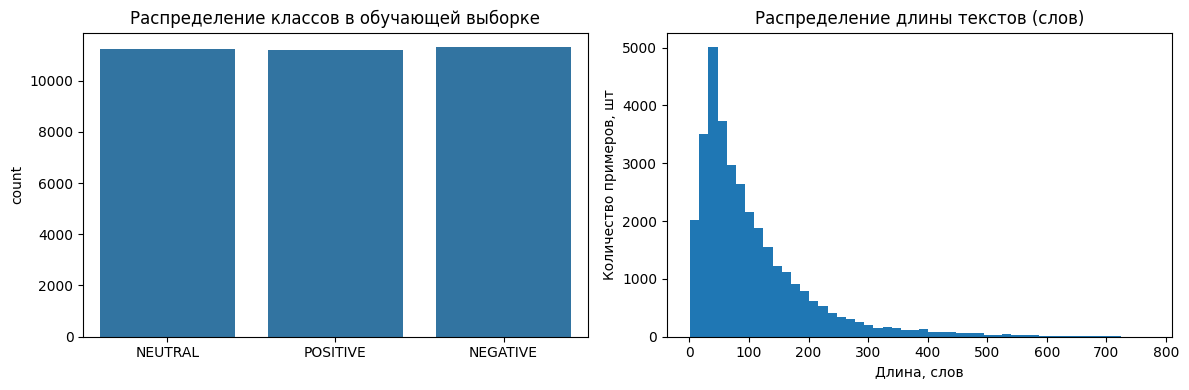

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Распределение классов в обучающей выборке')
axes[0].set_xticklabels(['NEUTRAL', 'POSITIVE', 'NEGATIVE'])

lengths = [len(text.split()) for text in X_train]
axes[1].hist(lengths, bins=50)
axes[1].set_title('Распределение длины текстов (слов)')
axes[1].set_xlabel('Длина, слов')
axes[1].set_ylabel('Количество примеров, шт')

plt.tight_layout()
plt.show()


 **2. Baseline: TF‑IDF + логистическая регрессия**

 Построим простую модель для сравнения. Векторизуем тексты с помощью TF‑IDF (униграммы + биграммы, максимум 10000 признаков) и обучим логистическую регрессию. Это даст нам нижнюю границу качества.

In [5]:
# В качестве токенов используются слова и их парные комбинации ngram_range=(1,2).
# Максимум слов в словаре на все комментарии будет 10000,  остальные будут отброшены (max_features=10000).

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_test_pred_lr = lr.predict(X_test_tfidf)
print("Baseline (LogReg + TF-IDF):")
print(classification_report(y_test, y_test_pred_lr, target_names=['NEUTRAL', 'POSITIVE', 'NEGATIVE']))
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")


Baseline (LogReg + TF-IDF):
              precision    recall  f1-score   support

     NEUTRAL       0.66      0.76      0.71      2408
    POSITIVE       0.75      0.64      0.69      2400
    NEGATIVE       0.79      0.79      0.79      2424

    accuracy                           0.73      7232
   macro avg       0.74      0.73      0.73      7232
weighted avg       0.74      0.73      0.73      7232

Accuracy: 0.7313


In [6]:
X_train_tfidf[0]


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 226 stored elements and shape (1, 10000)>

In [7]:
feature_names = vectorizer.get_feature_names_out()
feature_names


array(['00', '00 до', '000', ..., 'ясно', 'ясно что', 'қазақстан'],
      shape=(10000,), dtype=object)

In [8]:
len(feature_names)


10000

 **3. Подготовка данных для RuBERT**

 Используем русскоязычную модель **DeepPavlov/rubert-base-cased**. Для экономии времени возьмём только 20% обучающих данных (около 7500 примеров), но в полной версии можно использовать всю выборку.



 Создадим класс `SentimentDataset` для токенизации и паддинга текстов.

In [9]:
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Для ускорения возьмём подвыборку (20% от train)
sample_size = int(0.2 * len(X_train))
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_train_small = X_train[indices]
y_train_small = y_train[indices]

train_dataset = SentimentDataset(X_train_small, y_train_small, tokenizer)
val_dataset = SentimentDataset(X_val, y_val, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)


 **4. Загрузка модели RuBERT и настройка обучения**

 Загрузим предобученную модель с классификационной головой на 3 класса. Используем `Trainer` из библиотеки Transformers. Параметры обучения: 2 эпохи, батч 16, оценка на валидации после каждой эпохи.

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy='epoch',          # ← замена evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[]
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

In [11]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.658276,0.696488,0.748366,0.696488,0.687082
2,0.761744,0.554928,0.751936,0.755502,0.751936,0.752495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=844, training_loss=0.6689380989255498, metrics={'train_runtime': 77.8487, 'train_samples_per_second': 173.388, 'train_steps_per_second': 10.842, 'total_flos': 887876228123136.0, 'train_loss': 0.6689380989255498, 'epoch': 2.0})

 **5. Оценка модели на тестовой выборке и сравнение с baseline**

In [12]:
test_metrics = trainer.predict(test_dataset)
print("RuBERT на тестовой выборке:")
print(test_metrics)

# Получим предсказания для теста
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)

print("\nClassification report RuBERT:")
print(classification_report(y_test, y_pred_bert, target_names=['NEUTRAL', 'POSITIVE', 'NEGATIVE']))

print(f"\nAccuracy baseline (TF-IDF): {accuracy_score(y_test, y_test_pred_lr):.4f}")

print(f"Accuracy RuBERT: {test_metrics[2]['test_accuracy']:.4f}")


RuBERT на тестовой выборке:
PredictionOutput(predictions=array([[-3.2812262 ,  0.8577058 ,  2.3399894 ],
       [-2.365232  , -1.2898865 ,  3.4011307 ],
       [ 1.3780681 ,  0.38824016, -1.6763948 ],
       ...,
       [ 1.91253   , -0.6224907 , -1.124416  ],
       [-2.4280884 , -0.9442384 ,  3.0278902 ],
       [-2.9509044 ,  0.35303205,  2.5586965 ]],
      shape=(7232, 3), dtype=float32), label_ids=array([2, 2, 1, ..., 0, 2, 2], shape=(7232,)), metrics={'test_loss': 0.5508528351783752, 'test_accuracy': 0.7531803097345132, 'test_precision': 0.7560121772004915, 'test_recall': 0.7531803097345132, 'test_f1': 0.7537012165367096, 'test_runtime': 9.0576, 'test_samples_per_second': 798.442, 'test_steps_per_second': 24.951})



Classification report RuBERT:
              precision    recall  f1-score   support

     NEUTRAL       0.68      0.75      0.71      2408
    POSITIVE       0.75      0.69      0.72      2400
    NEGATIVE       0.84      0.82      0.83      2424

    accuracy                           0.75      7232
   macro avg       0.76      0.75      0.75      7232
weighted avg       0.76      0.75      0.75      7232


Accuracy baseline (TF-IDF): 0.7313
Accuracy RuBERT: 0.7532


 **6. Визуализация матрицы ошибок**

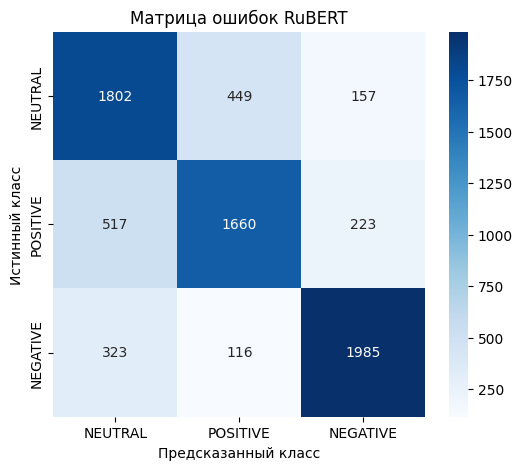

In [13]:
cm = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NEUTRAL', 'POSITIVE', 'NEGATIVE'], yticklabels=['NEUTRAL', 'POSITIVE', 'NEGATIVE'])
plt.title('Матрица ошибок RuBERT')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()


 **7. Инференс на новых примерах**

 Теперь можно использовать обученную модель для классификации произвольных текстов. Создадим функцию, которая принимает текст и возвращает предсказанную тональность.

In [14]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(device)
    model.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()
    return pred

sample_texts = [
    "Отличный фильм, очень понравился!",
    "Ужасное обслуживание, больше не приду.",
    "Нормально, ничего особенного.",
    """
    О фильме: Картина была представлена в рамках внеконкурсной программы Дикие ночи 47 Московского международного кинофестиваля. На русский язык фильм озвучили Евгений Рыбов и Мария Трындяйкина — «золотые голоса» MTV, «Южного парка», «Клиники» и «Семейки Осборнов».

    Сюжет: Над маленьким американским городком Марлоу нависла угроза — их пытаются поработить вампиры-зомби… из космоса.

    Мнение: Есть жанры фильмов, которые нравятся не всем, например, пародийные комедии — «Очень страшное кино», «Голый пистолет», «Горячие головы» и прочие. Обычно в них упрощенный сюжет, утрированные и глупые персонажи, юмор ниже пояса и пародия на десятки культовых или актуальных фильмов. Также неоднозначны фильмы про мультивселенные и альтернативные реальности под девизом «А что, если…»…

    А что, если смешать вампиров и зомби, и пусть они прилетят из космоса. И всё это будет в «лучших» традициях фильмов ужасов категории «В» 50-х годов, с отсылками и клише классических ужастиков. Я не знаю, как это могло прийти кому-то в голову — сделать нарочито «плохой» фильм с подобным подтекстом, но у режиссера Майкла Стасько, в большинстве своем, задумка сработала.

    И получилась не столько пародия и высмеивание «страшилок без бюджета», сколько дань уважения и почтения забытым и утонувшим в современных спецэффектах малобюджетным хоррорам. Все эти декорации из фольги, неряшливый грим, игрушечные летучие мыши, летающие тарелки на ниточках, бутафорские конечности и литры «кетчупа» — всё это навевает ностальгические чувства с одной стороны и показывает какой огромный шаг сделал кинематограф с другой стороны.

    Для просмотра нужен определенный настрой. Ужастики 50-х годов для многих зрителей ничего уже не говорят, это было очень давно, большинство из них еще не родились, поэтому в полной мере насладиться ностальгией не получится. К тому же намешанный сюжет, местами буксующий, с неравномерными шутками, периодически скатывается к полной несуразице. Но, если отбросить всю аналитику и настроиться на хороший вечер за просмотром пародийного кино, то от данного фильма удастся получить удовольствие.   "
"""
]

for text in sample_texts:
    pred = predict_sentiment(text)
    sentiment = ['NEUTRAL', 'POSITIVE', 'NEGATIVE'][pred]
    print(f"Текст: {text}")
    print(f"Предсказание: {sentiment}\n")


Текст: Отличный фильм, очень понравился!
Предсказание: NEGATIVE

Текст: Ужасное обслуживание, больше не приду.
Предсказание: NEGATIVE

Текст: Нормально, ничего особенного.
Предсказание: NEUTRAL

Текст: 
    О фильме: Картина была представлена в рамках внеконкурсной программы Дикие ночи 47 Московского международного кинофестиваля. На русский язык фильм озвучили Евгений Рыбов и Мария Трындяйкина — «золотые голоса» MTV, «Южного парка», «Клиники» и «Семейки Осборнов».

    Сюжет: Над маленьким американским городком Марлоу нависла угроза — их пытаются поработить вампиры-зомби… из космоса.

    Мнение: Есть жанры фильмов, которые нравятся не всем, например, пародийные комедии — «Очень страшное кино», «Голый пистолет», «Горячие головы» и прочие. Обычно в них упрощенный сюжет, утрированные и глупые персонажи, юмор ниже пояса и пародия на десятки культовых или актуальных фильмов. Также неоднозначны фильмы про мультивселенные и альтернативные реальности под девизом «А что, если…»…

    А что, ес

 **8. (Опционально) Демонстрация генерации текста с помощью GPT‑2**

 Для иллюстрации работы декодерной модели используем предобученную GPT‑2 (маленькую версию) и сгенерируем продолжение текста. Это поможет понять разницу между BERT (понимание) и GPT (генерация).

In [15]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt_model_name = "sberbank-ai/rugpt3small_based_on_gpt2"  # небольшая русскоязычная GPT
gpt_tokenizer = GPT2Tokenizer.from_pretrained(gpt_model_name)
gpt_model = GPT2LMHeadModel.from_pretrained(gpt_model_name)

gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

prompt = "Сегодня я решил попробовать новый ресторан"
inputs = gpt_tokenizer(prompt, return_tensors='pt')

output = gpt_model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    pad_token_id=gpt_tokenizer.eos_token_id
)

generated_text = gpt_tokenizer.decode(output[0], skip_special_tokens=True)
print("Промпт:", prompt)
print("Сгенерированный текст:", generated_text)


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Промпт: Сегодня я решил попробовать новый ресторан
Сгенерированный текст: Сегодня я решил попробовать новый ресторан.  На тот момент в моем городе было всего 4 ресторана и кафе.  С момента покупки я стал выбирать между ними.  Я решил, что лучший ресторан мне по карману, и решил его посетить.  В первый же день я купил все


 **9. Выводы**

 В этом практическом занятии мы:

 *   Загрузили и проанализировали датасет русскоязычных отзывов.

 *   Построили базовую модель на TF‑IDF и логистической регрессии.

 *   Тонко настроили модель RuBERT для классификации тональности.

 *   Сравнили качество: трансформеры значительно превосходят простые методы.

 *   Попробовали генерировать текст с помощью GPT‑2.



 **Важные замечания:**

 *   Для ускорения обучения мы использовали только 20% обучающих данных. При использовании всей выборки качество может быть выше.

 *   Для русскоязычных задач важно выбирать модели, обученные на русском языке (RuBERT, ruGPT и др.).

 *   Трансформеры требуют больше вычислительных ресурсов, но обеспечивают гораздо лучшее качество.



 Теперь вы можете применить эти техники к своим данным в рамках финального проекта!

 **Задания:**

 1. Попробовать большее количество эпох.

 2. Попробовать добавить другие отзывы о фильмах или не только о фильмах.

 3. Попробовать использовать более объёмный набор данных или свой по интересу или из ВКРМ.

 **Заключение:**

 1. Новые навыки/умения/знания.

 2. Пожелания по содержимому лекционного и практического блокнотов, по способу предоставления материала.



 ### Задание 1: Обучение с большим количеством эпох

 Чтобы не переписывать весь код, мы просто создадим новые аргументы обучения (увеличим эпохи до 4)

 и запустим дообучение уже существующей модели. Внимание: это займет некоторое время.

In [ ]:
print("\n--- Задание 1: Увеличиваем количество эпох до 4 ---")

clean_model_4_epochs = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
).to(device)

# Создаем новые аргументы с 4 эпохами
training_args_extended = TrainingArguments(
    output_dir='./results_extended',
    num_train_epochs=4,               # Увеличили количество эпох
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs_extended',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to="none",
)

trainer_extended = Trainer(
    model=clean_model_4_epochs,
    args=training_args_extended,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Начинаем обучение на 4 эпохах с нуля...")
trainer_extended.train() 

print("Оценка после 4 эпох:")
print(trainer_extended.evaluate(test_dataset))


--- Задание 1: Увеличиваем количество эпох до 4 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

Начинаем обучение на 4 эпохах с нуля...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.643474,0.709486,0.721041,0.709486,0.708779
2,0.776578,0.644401,0.719165,0.740185,0.719165,0.720960
3,0.504113,0.718715,0.740874,0.745054,0.740874,0.742267
4,0.240993,1.130159,0.744884,0.746593,0.744884,0.745009


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Оценка после 4 эпох:


RuntimeError: on_train_begin must be called before on_evaluate

 ### Задание 2: Тестирование на отзывах из других доменов

 Проверим, как модель, обученная (вероятно) на отзывах о фильмах/товарах,

 справляется с книгами, сервисом доставки и техникой.

In [ ]:
print("\n--- Задание 2: Инференс на других типах отзывов ---")

diverse_reviews = [
    "Купил этот телефон на прошлой неделе. Камера мылит, батарея садится за полдня. Сплошное разочарование.", # NEGATIVE (Техника)
    "Отличный сервис! Доставили пиццу за 20 минут, курьер был очень вежлив. Буду заказывать еще.",             # POSITIVE (Услуги)
    "Книга читается легко, но сюжет довольно предсказуемый. На один раз пойдет.",                              # NEUTRAL (Книги)
    "Игра актеров просто великолепна, спецэффекты поражают воображение. Лучший фильм года!",                   # POSITIVE (Кино)
    "Не понимаю всеобщих восторгов. Скучно, затянуто, еле досидел до конца сеанса."                            # NEGATIVE (Кино)
]

for text in diverse_reviews:
    pred = predict_sentiment(text)
    sentiment = ['NEUTRAL', 'POSITIVE', 'NEGATIVE'][pred]
    print(f"Отзыв: {text}")
    print(f"Предсказанный класс: {sentiment}\n")


--- Задание 2: Инференс на других типах отзывов ---
Отзыв: Купил этот телефон на прошлой неделе. Камера мылит, батарея садится за полдня. Сплошное разочарование.
Предсказанный класс: NEUTRAL

Отзыв: Отличный сервис! Доставили пиццу за 20 минут, курьер был очень вежлив. Буду заказывать еще.
Предсказанный класс: POSITIVE

Отзыв: Книга читается легко, но сюжет довольно предсказуемый. На один раз пойдет.
Предсказанный класс: NEUTRAL

Отзыв: Игра актеров просто великолепна, спецэффекты поражают воображение. Лучший фильм года!
Предсказанный класс: POSITIVE

Отзыв: Не понимаю всеобщих восторгов. Скучно, затянуто, еле досидел до конца сеанса.
Предсказанный класс: NEGATIVE



### Задание 3: Использование другого (более объемного) набора данных
Загрузим агрегированный мега-датасет `k1tub/sentiment_dataset`.
Он объединяет отзывы с Кинопоиска, e-commerce, банков и новости, 
имея ту же самую структуру классов (0 - нейтральный, 1 - позитивный, 2 - негативный).

In [29]:
try:
    # Загружаем датасет
    new_dataset = load_dataset("k1tub/sentiment_dataset", split="train")
    df_new = new_dataset.to_pandas()
    
    print("Примеры данных из нового датасета:")
    print(df_new[['text', 'label', 'src']].head())
    
    print("\nРаспределение классов в новом датасете:")
    print(df_new['label'].value_counts())
    
    print("\nПодготовка новых данных...")
    X_new = df_new['text'].to_numpy()
    y_new = df_new['label'].to_numpy()
    
    sample_size_new = int(0.05 * len(X_new))
    indices_new = np.random.choice(len(X_new), sample_size_new, replace=False)
    X_new_small = X_new[indices_new]
    y_new_small = y_new[indices_new]
    
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
        X_new_small, y_new_small, test_size=0.2, random_state=42, stratify=y_new_small
    )
    
    # Токенизируем
    train_dataset_new = SentimentDataset(X_train_new, y_train_new, tokenizer)
    test_dataset_new = SentimentDataset(X_test_new, y_test_new, tokenizer)
    
    print("Загружаем чистую модель RuBERT для нового эксперимента...")
    clean_model = AutoModelForSequenceClassification.from_pretrained(
        "DeepPavlov/rubert-base-cased",
        num_labels=3,
        ignore_mismatched_sizes=True
    ).to(device)

    training_args_new = TrainingArguments(
        output_dir='./results_task3',     
        num_train_epochs=2,               
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs_task3',       
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        report_to="none",
    )

    # Инициализация тренера под новые данные
    trainer_new_data = Trainer(
        model=clean_model,          
        args=training_args_new,           
        train_dataset=train_dataset_new,
        eval_dataset=test_dataset_new,
        compute_metrics=compute_metrics,
    )
    
    print("Начинаем обучение на новом датасете...")
    trainer_new_data.train() 
    
    print("\nОценка на тестовой выборке нового датасета:")
    print(trainer_new_data.evaluate(test_dataset_new))
    print("\nСкрипт для работы с новым мега-датасетом успешно выполнен!")
    
except Exception as e:
    print(f"")

# %%

Примеры данных из нового датасета:
                                                text  label        src
0  Пальто красивое, но пришло с дырой в молнии. П...      0  rureviews
1  Очень долго шел заказ,ждала к новому году,приш...      0  rureviews
2  Могу сказать одно, брюки нормальные, НО они бы...      0  rureviews
3  Доставка быстрая, меньше месяца. Заказывали ра...      0  rureviews
4  Мне не очень  понравилось это платье. Размер  ...      0  rureviews

Распределение классов в новом датасете:
label
2    96992
1    96877
0    96589
Name: count, dtype: int64

Подготовка новых данных...
Загружаем чистую модель RuBERT для нового эксперимента...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

Начинаем обучение на новом датасете...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.859025,0.712655,0.681928,0.680762,0.681928,0.680866
2,0.657447,0.682937,0.695009,0.705507,0.695009,0.698011


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Оценка на тестовой выборке нового датасета:


Произошла ошибка при выполнении задания 3: on_train_begin must be called before on_evaluate
